# Ridge Regression and Bayesian Linear Regression

Under certain assumptions, Ridge Regression can be viewed as a special case of Bayesian Inference.
That is, if we assume the prior $p(w)$ follows a normal distribution with independent weights:

$$
p(\mathbf{w}) = \mathcal{N}(0;\sigma^2_p\mathbf{I})
$$

and the likelihood is also normally distributed with the form

$$
p(y_i|\mathbf{w},\mathbf{x_i}) = \mathcal{N}(y_i;\mathbf{w}^T\mathbf{x_i},\sigma_n^2)
$$

then calculating the MAP

\begin{align*}
\mathbf{\hat{w}} &= \text{arg} \min p(\mathbf{w}|\mathbf{x_i}_{1:n},y_{1:n}) \\
                 &= \text{arg} \min \sum_{i = 1}^n(y_i - \mathbf{w}^T\mathbf{x_i})^2 + \frac{\sigma_n^2}{\sigma_p^2}||w||^2_2
\end{align*}

optimizes the same objective function as Ridge Regression.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pai import BLR, RidgeRegression
from selection import cross_validation
from scoring import mean_squared_error

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x_base = np.linspace(-5, 5, 100).reshape((100, 1))
x = rng.uniform(-5, 5, size=(100, 1))
y = x + rng.normal(size=(100, 1)) + 2

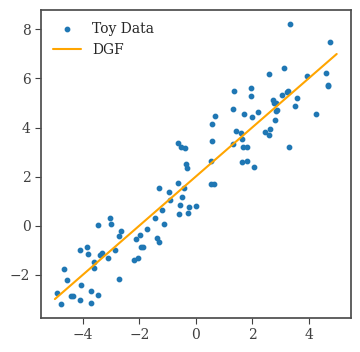

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(x, y, label="Toy Data", s=10)
ax.plot(x_base, x_base + 2, label="DGF", color="orange")
ax.legend()

plt.show()

# Ridge Regression

In [4]:
ridge = RidgeRegression(lam=0.9)
ridge = ridge.fit(x, y)

pred_y = ridge.predict(x_base)

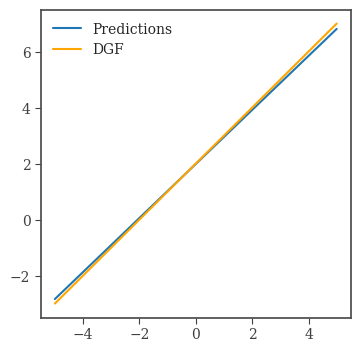

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(x_base, pred_y, label=f"Predictions")
ax.plot(x_base, x_base + 2, label="DGF", color="orange")
ax.legend()

plt.show()

## Bayesian Linear Regression

Bayesian Linear Regression is a similar technique, as it also predicts a linear function.
In Ridge Regression, the predictive distribution is

$$
p(y^*|\mathbf{x}^*,\hat{w}) = \mathcal{N}(y^*;\mathbf{w}^T\mathbf{x}^*,\sigma_n^2)
$$

. BLR, on the other hand, allows for separation between aleatoric and epistemic uncertainty.
The predictive distribution changes to

$$
p(y^*|\mathbf{x}^*,\hat{w}) = \mathcal{N}(y^*;\mathbf{w}^T\mathbf{x}^*,\sigma_n^2 + \mathbf{x}^{*T}\bar{\Sigma}\mathbf{x}^*)
$$

The epistemic uncertainty $\mathbf{x}^{*T}\bar{\Sigma}\mathbf{x}^*$ can be reduced by gathering more data, whereas the aleatoric one
$\sigma_n^2$ is irreducible.

In [10]:
blr = BLR(lam=1.0)
blr = blr.fit(x, y)

pred_mu, pred_cov = blr.predict(x_base)

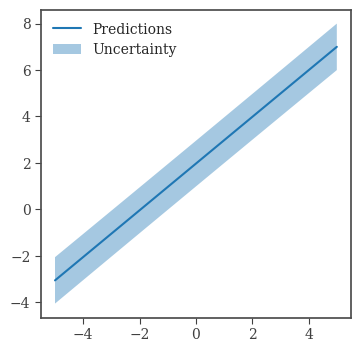

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(x_base, pred_mu, label=f"Predictions")

std = np.diag(pred_cov) ** 0.5
ax.fill_between(x_base.ravel(), pred_mu - std, pred_mu + std, label="Uncertainty", alpha=0.4)

ax.legend()

plt.show()

## Cross Validation

Cross validation can be used to estimate the variance of the prior and noise.
The hyperparameter $\lambda$ is defined through the fraction

$$
\lambda = \frac{\sigma_n^2}{\sigma_p^2}
$$

Thus, we can optimize $\lambda$, then estimate $\sigma_n^2$ through

$$
\sigma_n^2 = \frac{1}{n}\sum_{i = 1}^{n}(y_i - \mathbf{\hat{w}}^T\mathbf{x}_i) ** 2
$$

and calculate $\sigma_p^2$ by solving for it.

In [14]:
for lam in [0.001, 0.01, 0.1, 1, 2, 3, 4, 5, 10, 20, 50, 100]:
    blr = BLR(lam=lam)
    score = cross_validation(blr, x, y, mean_squared_error, k=10)

    print(f"BLR with lam = {lam} CV-MSE: {score:.4f}")
    print(f"    Noise: {blr.sigma_n2_:.2f}")
    print(f"    Prior: {blr.sigma_p2_:.2f}")

BLR with lam = 0.001 CV-MSE: 0.9992
    Noise: 1.00
    Prior: 1000.28
BLR with lam = 0.01 CV-MSE: 0.9759
    Noise: 0.94
    Prior: 93.75
BLR with lam = 0.1 CV-MSE: 1.0070
    Noise: 0.95
    Prior: 9.47
BLR with lam = 1 CV-MSE: 0.9980
    Noise: 0.95
    Prior: 0.95
BLR with lam = 2 CV-MSE: 0.9915
    Noise: 1.01
    Prior: 0.50
BLR with lam = 3 CV-MSE: 1.0078
    Noise: 0.97
    Prior: 0.32
BLR with lam = 4 CV-MSE: 1.0138
    Noise: 0.99
    Prior: 0.25
BLR with lam = 5 CV-MSE: 1.0222
    Noise: 0.96
    Prior: 0.19
BLR with lam = 10 CV-MSE: 1.0273
    Noise: 1.03
    Prior: 0.10
BLR with lam = 20 CV-MSE: 1.1516
    Noise: 1.14
    Prior: 0.06
BLR with lam = 50 CV-MSE: 1.5269
    Noise: 1.50
    Prior: 0.03
BLR with lam = 100 CV-MSE: 2.2106
    Noise: 2.23
    Prior: 0.02
